In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from fredapi import Fred
from sklearn.covariance import LedoitWolf,OAS
import pandas as pd
import warnings
from rich.console import Console
from rich.panel import Panel
from tqdm import tqdm


warnings.filterwarnings("ignore")
df = pd.read_csv("ML csv/data-camille.csv", sep=";", decimal=",")
df = df.rename(columns={"Column1": "Date","Column2": "BENCH",})
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

In [25]:
#return a df of size (lookback, number of sectors) with log returns
def GetReturn(df,date,lookback):
    date=pd.to_datetime(date)
    if date not in df["Date"].values:#add breaker if windows not in df
        raise ValueError("Date not in dataframe")
    returns_df=df.copy()
    returns_df=returns_df.drop(columns=["BENCH"])

    date_index = returns_df.index[returns_df["Date"] == date][0]
    returns_df=returns_df[(returns_df.index<=date_index) & (returns_df.index>=date_index-lookback) ]
    returns_df.drop(columns="Date",inplace=True)

    returns_df = np.log(returns_df/ returns_df.shift(1))
    returns_df.dropna(inplace=True)
    #print(returns_df.std().mean()) #verification if std is around 1% daily

    return returns_df

#return a df of size (lookback, 1) with log returns of SPX
def GetReturnSPX(df,date,lookback):
    date=pd.to_datetime(date)
    if date not in df["Date"].values:#add breaker if windows not in df
        raise ValueError("Date not in dataframe")
    returns_df = df[["Date","BENCH"]].copy()
    date_index = returns_df.index[returns_df["Date"] == date][0]

    returns_df=returns_df[(returns_df.index<=date_index) & (returns_df.index>=date_index-lookback) ]
    returns_df.drop(columns="Date",inplace=True)
    returns_df = np.log(returns_df/ returns_df.shift(1))
    returns_df.dropna(inplace=True)
    #print(returns_df.std().mean()) #verification if std is around 1% daily

    return returns_df


In [26]:
#return a cov matrix of size (number of sectors, number of sectors) we use lookback to have different window sizes
def GetSigma(df,date,lookback):
    returns_df=GetReturn(df,date,lookback=lookback)
    #covariance matric from returns_df
    sigma_windowed=returns_df.cov()

    return sigma_windowed

#return the n by n variance covariance matrix by ledoitwolf
def get_shrunk_covariance(df,date,lookback):
    returns=GetReturn(df,date,lookback)

    lw = OAS()
    lw.fit(returns)
    shrunk_cov = lw.covariance_
    if isinstance(returns, pd.DataFrame):
        shrunk_cov = pd.DataFrame(shrunk_cov,index=returns.columns,columns=returns.columns)

    return shrunk_cov


#can be used if we want to ban specifics periods from our backtesting
def getSigmaModified(df,date,lookback,listofbanneddays,periodison=False):
    date=pd.to_datetime(date)
    if date not in df["Date"].values:#add breaker if windows not in df
        raise ValueError("Date not in dataframe")

    returns_df=df.copy()
    returns_df=returns_df.drop(columns=["BENCH"])

    date_index = returns_df.index[returns_df["Date"] == date][0]
    returns_df=returns_df[(returns_df.index<=date_index) & (returns_df.index>=date_index-lookback)]
    #days selection

    #banned days
    for banned_date in listofbanneddays:
        mask = returns_df["Date"] == banned_date
        if mask.any():
            print("got one :", banned_date)
            returns_df.loc[mask, :] = np.nan

    returns_df.drop(columns="Date",inplace=True)
    returns_df.dropna(inplace=True)

    #calculation of returns
    returns_df = np.log(returns_df/ returns_df.shift(1))
    returns_df.dropna(inplace=True)

    #covaraicne matrix using shrinkage
    lw = OAS()
    lw.fit(returns_df)
    shrunk_cov = lw.covariance_

    if isinstance(returns_df, pd.DataFrame):
        shrunk_cov = pd.DataFrame(
            shrunk_cov,
            index=returns_df.columns,
            columns=returns_df.columns
        )


    return shrunk_cov

In [27]:
#compute risk free dataframe using API from FRED and get the cumulative risk free rate in a df
def GetRfDataframe(df):
    fred = Fred(api_key="5c742a53d96bd3085e9199dcdb5af60b")
    riskfree = fred.get_series('DFF')
    #riskfree = fred.get_series('DTB1MO') #other data source to compute rf

    riskfree = riskfree.to_frame(name='FedFunds')
    riskfree.index.name = "Date"
    riskfree = riskfree[riskfree.index >= "2000-01-01"]
    riskfree["FedFunds"]=riskfree["FedFunds"]/100
    list_days_open = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    list_days_full = pd.to_datetime(riskfree.index, dayfirst=True, errors="coerce")

    list_days_open=[pd.to_datetime(date) for date in list_days_open]
    list_days_full=[pd.to_datetime(date) for date in list_days_full]


    list_days_open_pondered=[]
    riskfree_list=[]
    count_list=[]
    timestamp=0
    while timestamp < len(list_days_full)-1:

      if list_days_full[timestamp+1] in list_days_open:
            list_days_open_pondered.append(list_days_full[timestamp])
            riskfree_list.append(riskfree["FedFunds"].loc[list_days_full[timestamp]])
            count_list.append(1)
            timestamp += 1

      else:
          count = 0
          timestampbis = timestamp
          while (timestamp + 1 < len(list_days_full)) and (list_days_full[timestamp + 1] not in list_days_open):
              timestamp += 1
              count += 1

          list_days_open_pondered.append(list_days_full[timestampbis])  # jour de départ
          riskfree_list.append(riskfree["FedFunds"].loc[list_days_full[timestampbis]])
          count_list.append(count+1)
          timestamp += 1

    RfDf=pd.DataFrame({"Date":list_days_open_pondered,"Rf":riskfree_list,"Count":count_list})
    RfDf=RfDf.set_index("Date")
    return RfDf


#Using previous dataframe, we keep only the selected risk free for the selected dates and compute it
def GetRiskFree(df,date,lookback,RfDf):
    positionOfStartDate=df.index[df["Date"]==pd.to_datetime(date)][0]-lookback
    startDate=pd.to_datetime(df.iloc[positionOfStartDate,0])
    endDate=pd.to_datetime(date)
    RfDf=RfDf[(RfDf.index >= startDate) & (RfDf.index <= endDate )].copy()
    CumulativeRf=[]

    for i in range(len(RfDf)):
      if i==0:
        CumulativeRf.append(pow((1+RfDf["Rf"].iloc[i]),(RfDf["Count"].iloc[i]/360)))
      else:
        CumulativeRf.append(pow((1+RfDf["Rf"].iloc[i]),(RfDf["Count"].iloc[i]/360))*CumulativeRf[i-1])

    RfDf["CumulativeRf"]=CumulativeRf
    RfDf["CumulativeRf"]= RfDf["CumulativeRf"]-1

    return RfDf["CumulativeRf"].iloc[-1]


In [28]:
#return the weight vector 1xn_assets, will be usefull for the equal weight computation
def GetWeight(df):
    length_df=df.shape[1]-2 #we remove two since we have the benchmark + the date columns
    weight_vector=np.zeros((length_df,1))
    for _ in range(0,length_df):
        weight_vector[_]=1/length_df

    return weight_vector


In [29]:
#return the Q Matrix
def QMatrixCalculation(proportion,performerc_daily,dailyperf_market):
    Q=np.zeros((proportion,1))
    for i in range(proportion):
        Q[i,0]=(performerc_daily[i][0]-dailyperf_market)/2

    return Q

In [81]:
def GetPMatrix(df,date, lookback,proportion=3):

    AssetColumns=df.columns.drop(["Date","BENCH"]).tolist()

    bestperformer = []
    performerc = []
    performerc_daily=[]

    #starting and ending dates
    endDateIndex=df.index[df["Date"]==pd.to_datetime(date)][0]
    startDateIndex=df.index[df["Date"]==pd.to_datetime(date)][0]-lookback


    for i in range(2, df.shape[1]):#loop through asset columns
        performerc.append((((float(df.iloc[endDateIndex, i]) / float(df.iloc[startDateIndex, i]) - 1) * 100), i - 2,df.columns[i])) #pos of best stock in a tuple
        # with its return
        performerc_daily.append(((float(df.iloc[endDateIndex, i]) / float(df.iloc[startDateIndex, i])) ** (1/lookback) - 1, i - 2,df.columns[i])) #daily version

    #get the long part
    performerc.sort(reverse=True)
    performerc_daily.sort(reverse=True)
    dailyperf_market = (float(df.iloc[endDateIndex, 1]) / float(df.iloc[startDateIndex, 1])) ** (1/lookback) - 1
    tempoperfdaily=[]
    countlong=proportion
    for i in range(countlong):
        bestperformer.append(performerc_daily[i][1])
        tempoperfdaily.append(performerc_daily[i])


    #get the short part
    countshort = np.sum(1 for x in performerc_daily if x[0] < -0.01) #significative loss useless for the moment
    countshort=proportion
    totalpos=countlong+countshort
    worstperf=[]
    for j in range(countshort):
        worstperf.append(performerc_daily[len(performerc_daily)-j-1][1])
        tempoperfdaily.append(performerc_daily[len(performerc_daily)-j-1])

    bestperformer=bestperformer+worstperf
    length_df=df.shape[1]-2

    #P matrix computation
    P=np.zeros((totalpos,length_df))
    for lineview in range(totalpos):
        for i in range(len(AssetColumns)):
            P[lineview,i]=-1/len(AssetColumns)
        P[lineview,bestperformer[lineview]]=1-1/len(AssetColumns)

    #Q matrix computation
    Q=QMatrixCalculation(totalpos,tempoperfdaily,dailyperf_market)

    return P, Q

In [82]:
#get the Omega matrix, representing the uncertainty of the views
def GetOmega(PMatrix, Sigma, c=0.99):
    factorC=(1/c-1)
    Omega=factorC*PMatrix@Sigma@np.transpose(PMatrix)
    return Omega

In [105]:
#implement the full backtest of the black and litterman model
def BlackAndLittermanModel(backtestStartDate, rebalancingFrequency, lookbackPeriod, df,RfDf,confidence=0.00001,proportion=1,tau=0.025,Lambda=3,modifiedlambda=0):

    Sigma=get_shrunk_covariance(df,backtestStartDate,lookback=63)
    PMatrix,Q= GetPMatrix(df,backtestStartDate, lookback=lookbackPeriod,proportion=proportion)
    Omega=GetOmega(PMatrix, Sigma, c=confidence)
    rf=GetRiskFree(df,backtestStartDate,lookbackPeriod,RfDf)
    weights = GetWeight(df)
    weights = np.array(weights).reshape(-1, 1)
    Lambda=3
    LambdaMarkowitz=3

    changingLambda=False
    if changingLambda==True:
        LambdaMarkowitz=3+0.05*GetLambda(df,backtestStartDate,timeofcalculation=90,RfDf=RfDf)
    else :
        LambdaMarkowitz=3

    #Master formula
    uimplied = Lambda * (Sigma @ weights) + rf
    optimizedReturn=(np.linalg.inv(np.linalg.inv(tau*Sigma)+np.transpose(PMatrix)@np.linalg.inv(Omega)@PMatrix)) @ (np.linalg.inv(tau*Sigma)@uimplied+np.transpose(PMatrix)@np.linalg.inv(Omega)@Q)


    #MarkowitzAllocation
    WeightBL=np.linalg.inv(Sigma)@(optimizedReturn-rf)/LambdaMarkowitz
    WeightRF  = 1.0 - float(np.sum(WeightBL))

    # Sanity check — use a float comparison, not a pandas truth test
    total = float(np.sum(WeightBL))
    if not np.isclose(total + WeightRF, 1.0, atol=1e-8):
        raise ValueError(f"Weights do not sum to 1: risky={total:.6f}, rf={WeightRF:.6f}")

    return WeightBL, WeightRF

In [108]:
console = Console()

#BACK TESTER
dfbacktest=df.copy()
dfbacktest["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
dfbacktest["MonthIndex"] = dfbacktest["Date"].dt.to_period("M")

df_length = dfbacktest.shape[1] - 2  # bcs of date and spx
last_rebalance = dfbacktest.loc[0, "Date"]  # première date
month_count = 0

#PARAMETERS
hold =3
hist = 12
proportion=4
Lambda=3
tau=0.025
confidence=0.75

console.print(Panel.fit("[bold cyan]📊 PORTFOLIO BACKTESTER[/bold cyan]\n""[dim]Black-Litterman Model[/dim]",border_style="cyan"))
console.print(f"\n[yellow]⚙️  Configuration :[/yellow]")
console.print(f"   • Hold period: [cyan]{hold}[/cyan] mois")
console.print(f"   • Historique: [cyan]{hist}[/cyan] mois")
console.print(f"   • Proportion: [cyan]{proportion}[/cyan]")
console.print(f"   • Lambda: [cyan]{Lambda:.4f}[/cyan]")
console.print(f"   • Confiance: [cyan]{confidence}[/cyan]")
console.print(f"   • Taux: [cyan]{tau}[/cyan]\n")
console.print("\n[yellow]⏳ Lancement du backtest...[/yellow]\n")


def Backtester(df,hold, hist, proportion,df_toBL, RfDf,confidence2,proportion2,tau2,Lambda2,start,modifiedlambda):
    Cash = pd.Series(0.0, index=df.index)
    StockQty = df.copy()
    StockQty.drop(columns="MonthIndex", inplace=True)
    StockQty.loc[:, :] = 0

    #starting data
    MoneyAtStart = 10000000
    interspaced=0
    #first ligne
    StockQty.loc[start, "Money"] = MoneyAtStart
    StockQty.loc[start, "BENCH"] = df.iloc[start, 1]
    StockQty.loc[start, "Date"] = df.iloc[start, 0]

    for i in tqdm(range(start,df.shape[0]), desc="Backtesting"):
      StockQty.iloc[i,0]=df.iloc[i,0]
      StockQty.iloc[i,1]=df.iloc[i,1]

      #calculer value
      if i==start :
            CurrentValue=MoneyAtStart
      else :
          CurrentValue=Cash.iloc[i-1]
          for stocks in range(2, StockQty.shape[1]-1):
              CurrentValue+=StockQty.iloc[i-1, stocks]*df.iloc[i, stocks]

      if interspaced>21*hold or i==start:
        interspaced=0

        BLWeight,RiskFreeAmount=BlackAndLittermanModel(str(df.iloc[i,0]),21*hold,hist*21,df_toBL,RfDf,confidence=confidence2,proportion=proportion2,tau=tau2,Lambda=Lambda2,modifiedlambda=modifiedlambda)
        w_rf = float(RiskFreeAmount)     # WeightRF
        Cash.iloc[i] = CurrentValue * w_rf

        for index in range(len(BLWeight)):
            StockQty.iloc[i, index + 2] = (BLWeight.iloc[index, 0] * CurrentValue) / df.iloc[i, index + 2]
      else :
        interspaced+=1
        for stocks in range(2,StockQty.shape[1]-1):
          StockQty.iloc[i,stocks]=StockQty.iloc[i-1,stocks]


        rf_daily = GetRiskFree(df,str(df.iloc[i,0]),1,RfDf)
        Cash.iloc[i] = Cash.iloc[i-1] * (1 + rf_daily)

      VolumeInMoney=0
      for assets in range(2, StockQty.shape[1]-1):
        VolumeInMoney+=(abs(StockQty.iloc[i, assets]-StockQty.iloc[i-1, assets]) * df.iloc[i, assets])

      AmountPayedInFee=VolumeInMoney*0.0002
      Cash.iloc[i] -= AmountPayedInFee

      invested_risky = 0.0
      for stocks in range(2, StockQty.shape[1]-1):
          invested_risky += StockQty.iloc[i, stocks] * df.iloc[i, stocks]
      StockQty.iloc[i,-1] = Cash.iloc[i] + invested_risky

    StockQty = StockQty.iloc[start:].reset_index(drop=True)
    return StockQty
RfDf=GetRfDataframe(df)
final = Backtester(dfbacktest, hold=hold, hist=hist, proportion=proportion, df_toBL=df,RfDf=RfDf,confidence2=confidence,proportion2=proportion,tau2=tau,Lambda2=Lambda,start=hist*21+10,modifiedlambda=True)

console.print("\n[green]✅ Backtest terminé avec succès ![/green]\n")

╭─────────────────────────╮
│ 📊 PORTFOLIO BACKTESTER │
│ Black-Litterman Model   │
╰─────────────────────────╯

⚙️  Configuration :

• Hold period: 3 mois

• Historique: 12 mois

• Proportion: 4

...

• Confiance: 0.75

• Taux: 0.025

⏳ Lancement du backtest...

Backtesting: 100%|██████████| 5521/5521 [00:47<00:00, 115.35it/s]


✅ Backtest terminé avec succès !

In [109]:
def backtest_ew_daily(df, initial_capital=10_000_000):
    asset_cols = df.columns.drop(['Date', 'BENCH'])
    data_assets = df[asset_cols]
    returns = data_assets.pct_change().dropna()
    ew_returns = returns.mean(axis=1)
    portfolio_value = initial_capital * (1 + ew_returns).cumprod()
    result = pd.DataFrame({'Date': df['Date'].iloc[1:],'ew': portfolio_value,'Daily_Return': ew_returns})

    return result

a=backtest_ew_daily(df)

In [110]:

# 1. On force le format Date pour être sûr qu'ils match avec le même type
final["Date"] = pd.to_datetime(final["Date"])
a["Date"] = pd.to_datetime(a["Date"])

# 2. Le merge fonctionnera maintenant
final_merged = final.merge(a[['Date', 'ew']], on='Date', how='left')

# 3. Calcul des normes
money_norm = (final_merged["Money"] / 10000000 * 100) - 100
ew_norm = (final_merged["ew"] / final_merged["ew"].dropna().iloc[0] * 100) - 100

df_plot = pd.DataFrame({
    "Date": final_merged["Date"],
    "Portfolio": money_norm,
    "ew": ew_norm
}).melt(id_vars="Date", var_name="Série", value_name="Évolution en %")

# 4. Affichage
fix = px.line(
    df_plot,
    x="Date",
    y="Évolution en %",
    color="Série",
    color_discrete_map={"ew": "red", "Portfolio": "green"},
    title="Evolution",
    template="plotly_white"
)

fix.update_layout(hovermode="x unified")
fix.show()

In [111]:
import plotly.express as px
import pandas as pd

# 1. Calcul des performances normalisées (Base 0)
# On part du principe que 'final' contient toutes les colonnes nécessaires
money_norm = (final["Money"] / 10000000 * 100) - 100
ew_norm = (final_merged["ew"] / final_merged["ew"].iloc[0] * 100) - 100
sxxt_norm = (final["BENCH"] / final["BENCH"].iloc[0] * 100) - 100

# 2. Création du DataFrame pour le plot
df_plot = pd.DataFrame({
    "Date": final["Date"],
    "Portfolio": money_norm,
    "EW": ew_norm,
    "SXXT": sxxt_norm
})

# 3. Transformation en format long (tidy data) pour Plotly
df_melted = df_plot.melt(
    id_vars="Date",
    var_name="Série",
    value_name="Évolution en %"
)

# 4. Affichage du graphique
fig = px.line(
    df_melted,
    x="Date",
    y="Évolution en %",
    color="Série",
    color_discrete_map={
        "Portfolio": "green",
        "EW": "#FFA500",    # Orange pour l'EW
        "SXXT": "red"       # Rouge pour l'indice
    },
    title="Comparaison de Performance : Portfolio vs EW vs SXXT",
    template="plotly_white"
)

# Amélioration de l'interactivité
fig.update_layout(
    hovermode="x unified",
    legend_title_text="Stratégies",
    yaxis_ticksuffix="%"
)

fig.show()

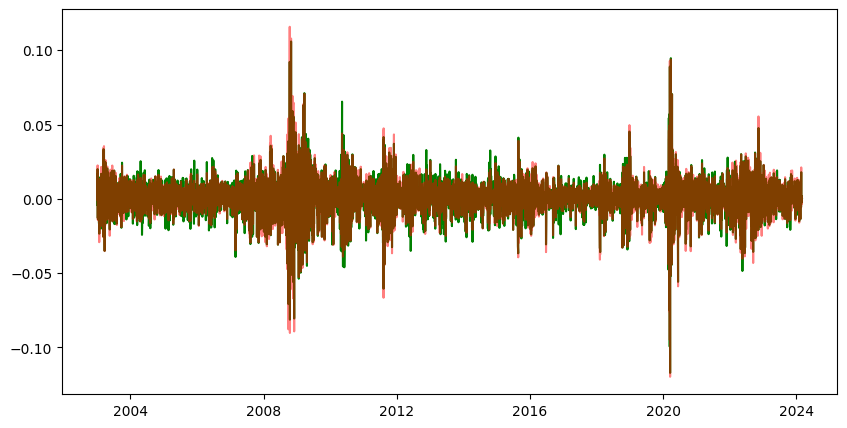

In [112]:
#MDD

MDDdf=final[["Date","BENCH","Money"]]
MDDdf["BENCH Returns"]=(MDDdf["BENCH"].pct_change()).dropna()
MDDdf["Portfolio Returns"]=(MDDdf["Money"].pct_change()).dropna()
MDDdf.drop(columns=["BENCH","Money"],inplace=True)
MDDdf.dropna(inplace=True)
MDDdf.head(4)


plt.figure(figsize=[10,5])
plt.plot(MDDdf["Date"],MDDdf["Portfolio Returns"],color="green")
plt.plot(MDDdf["Date"],MDDdf["BENCH Returns"],color="red",alpha=0.5)

plt.show()

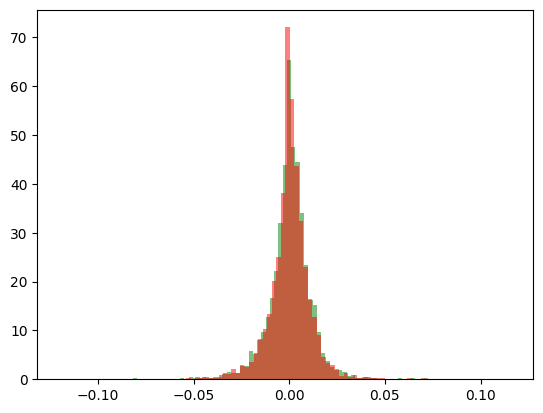

In [113]:
plt.figure()
plt.hist(MDDdf["Portfolio Returns"], bins=100, density=True,alpha=0.5,color="green")
plt.hist(MDDdf["BENCH Returns"], bins=100, density=True,color="red",alpha=0.5)

muPF = MDDdf["Portfolio Returns"].mean()
sigmaPF = MDDdf["Portfolio Returns"].std()

muBENCH = MDDdf["BENCH Returns"].mean()
sigmaBENCH = MDDdf["BENCH Returns"].std()

plt.show()

In [114]:
prices=final[["Date","Money","BENCH"]]
running_max_BENCH = prices["BENCH"].cummax()
drawdown_BENCH = prices["BENCH"] / running_max_BENCH- 1
running_max_PF=prices["Money"].cummax()
drawdown_PF = prices["Money"] / running_max_PF - 1
prices["drawdown_BENCH"]=drawdown_BENCH
prices["drawdown_PF"]=drawdown_PF

indexMDDBENCH=prices["drawdown_BENCH"].idxmin()
indexMDDPF= prices["drawdown_PF"].idxmin()

if indexMDDBENCH==indexMDDPF:
    print("Same MDD date")
    print("MDD : ",prices.iloc[indexMDDBENCH])
else :
    print("MDD BENCH : ",prices.iloc[indexMDDBENCH])
    print("MDD PF : ",prices.iloc[indexMDDPF])

Same MDD date
MDD :  Date              2009-03-09 00:00:00
Money                  8489456.893671
BENCH                          676.53
drawdown_BENCH              -0.567754
drawdown_PF                 -0.538892
Name: 1612, dtype: object


In [115]:
prices=final["BENCH"]
running_max = prices.cummax()
drawdown = prices / running_max - 1
mdd = drawdown.min()
print(mdd)

-0.5677538894035716


In [117]:
AnnualizedDf=final[["Date","BENCH","Money"]]
AnnualizedDf['Date'] = pd.to_datetime(AnnualizedDf['Date'])
AnnualizedDf['Year'] = AnnualizedDf['Date'].dt.year



YearList=AnnualizedDf["Year"].unique()
BENCHAnnualized=pd.DataFrame(columns=YearList)
StratAnnualized=pd.DataFrame(columns=YearList)



for year in YearList:
  compteurPerYear=0
  for i in AnnualizedDf.index:
    if AnnualizedDf.loc[i,"Year"]==year:
      if compteurPerYear==0:
        BENCHAnnualized.loc[compteurPerYear,year]=AnnualizedDf.loc[i,"BENCH"]
        StratAnnualized.loc[compteurPerYear,year]=AnnualizedDf.loc[i,"Money"]
      else :
        BENCHAnnualized.loc[compteurPerYear,year]=AnnualizedDf.loc[i,"BENCH"]/BENCHAnnualized.loc[0,year]*100-100
        StratAnnualized.loc[compteurPerYear,year]=AnnualizedDf.loc[i,"Money"]/StratAnnualized.loc[0,year]*100-100
      compteurPerYear+=1

for year in YearList:
  BENCHAnnualized.loc[0,year]=BENCHAnnualized.loc[0,year]/BENCHAnnualized.loc[0,year]*100-100
  StratAnnualized.loc[0,year]=StratAnnualized.loc[0,year]/StratAnnualized.loc[0,year]*100-100



BENCHAvg=[]
StratAvg=[]
for i in BENCHAnnualized.index:
  sumBENCH=0
  sumStrat=0
  for year in BENCHAnnualized.columns:
    sumBENCH+=BENCHAnnualized.loc[i,year]
    sumStrat+=StratAnnualized.loc[i,year]
  BENCHAvg.append(sumBENCH/len(YearList))
  StratAvg.append(sumStrat/len(YearList))

BENCHAnnualized=BENCHAnnualized.drop(columns=[2024]) #too much nan
StratAnnualized=StratAnnualized.drop(columns=[2024])

BENCHAvg=[]
StratAVG=[]

for i in BENCHAnnualized.index:
  sumBENCH=0
  sumStrat=0
  for year in BENCHAnnualized.columns:
    sumBENCH+=BENCHAnnualized.loc[i,year]
    sumStrat+=StratAnnualized.loc[i,year]
  BENCHAvg.append(sumBENCH/len(YearList))
  StratAVG.append(sumStrat/len(YearList))

dff = pd.DataFrame({"Index": (range(len(BENCHAvg))),"Portfolio": StratAVG,"BENCH": BENCHAvg})


fig = px.line(dff, x="Index", y=["BENCH","Portfolio"], color_discrete_map={"BENCH": "red","Portfolio": "green"})
fig.show()



In [ ]:
returns = final["Money"].pct_change().dropna()
returnsBENCH = final["BENCH"].pct_change().dropna()
window = 252
rolling_1y = (1 + returns).rolling(window).apply(np.prod, raw=True) - 1
rollingBENCH=(1+returnsBENCH).rolling(window).apply(np.prod, raw=True) -1
returndiff=rolling_1y-rollingBENCH
plt.figure()
dfreturnslapping=pd.DataFrame({"Date":final["Date"].iloc[1::],"BENCHreturns":rollingBENCH,"Pfreturns":rolling_1y,"returndiff":returndiff})
fig = px.line(dfreturnslapping,x=dfreturnslapping["Date"], y=["BENCHreturns","Pfreturns","returndiff"], color_discrete_map={"BENCHreturns": "red","Pfreturns": "green","returndiff": "blue"})
fig.show()
print(returndiff.mean())

In [ ]:
dailyvolBENCH=rollingBENCH.rolling(252).apply(np.std, raw=True)
dailyvolPF=rolling_1y.rolling(252).apply(np.std, raw=True)
annualizedvolBENCH=dailyvolBENCH
annualizedvolPF=dailyvolPF

check=np.full(annualizedvolBENCH.shape[0],0.02)

sharpePF=((rolling_1y-check)/annualizedvolPF).dropna()
sharpeBENCH=((rollingBENCH-check)/annualizedvolBENCH).dropna()
diffsharpe=sharpePF-sharpeBENCH
quickdf=pd.DataFrame({"Date":final["Date"].iloc[503::],"SharpeBENCH":sharpeBENCH,"SharpePF":sharpePF,"diff":diffsharpe})
plt.figure()
fig=px.line(quickdf,x="Date",y=["SharpeBENCH","SharpePF","diff"],color_discrete_map={"SharpeBENCH":"red","SharpePF":"green","diff": "blue"})
fig.show()
print(sharpePF.mean())
print(sharpeBENCH.mean())
print(diffsharpe.mean())

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

df2 = final[["Date", "BENCH", "Money"]].copy()
df2["Portfolio"] = df2["Money"]
df2.drop(columns="Money", inplace=True)
df2["Date"] = pd.to_datetime(df2["Date"], dayfirst=True)
df2.set_index("Date", inplace=True)

daily_returns = df2.pct_change()
daily_returns.dropna(inplace=True)

daily_returns["Volatility of the Benchmark"] = daily_returns['BENCH'].rolling(window=252).std() * np.sqrt(252)
daily_returns["Volatility of the Portfolio"] = daily_returns['Portfolio'].rolling(window=252).std() * np.sqrt(252)
data_to_plot = daily_returns.dropna()


fig = px.line(data_to_plot,
              x=data_to_plot.index,
              y=["Volatility of the Benchmark", "Volatility of the Portfolio"],
              labels={"value": "Volatility of the Benchmark", "variable": "Actif", "Date": "Date"},
              title="annualized vol : BENCH vs Portfolio")

fig.show()

In [ ]:
def calculate_historical_var_es(df, col_name='Money', confidence_level=0.95):


    returns = df[col_name].pct_change().dropna()

    cutoff = 1 - confidence_level

    var_value = returns.quantile(cutoff)

    worst_returns = returns[returns <= var_value]
    es_value = worst_returns.mean()

    return {
        "confidence_level": confidence_level,
        "VaR": -var_value,
        "ES": -es_value,
        "count_returns": len(returns),
        "count_breaches": len(worst_returns)
    }



def calculate_sharpe_ratio(df, col_name='close', risk_free_rate_annual=0.04):


    returns = (df[col_name] - df[col_name].shift(1)) / df[col_name].shift(1)
    returns = returns.dropna()
    rf_daily = risk_free_rate_annual / 252
    excess_returns = returns - rf_daily

    sharpe_daily = excess_returns.mean() / excess_returns.std()

    sharpe_annualized = sharpe_daily * np.sqrt(252)

    return sharpe_annualized


In [ ]:
print("Portfolio Risk Measures:")
print(calculate_historical_var_es(final, 'Money', 0.95))
print(f"Sharpe Ratio: {calculate_sharpe_ratio(final, 'Money', 0.03):.2f}")

print("\nBENCH Risk Measures:")
print(calculate_historical_var_es(final, 'BENCH', 0.95))
print(f"Sharpe Ratio: {calculate_sharpe_ratio(final, 'BENCH', 0.03):.2f}")

**BELOW ARE UN-USED FUNCTIONS, FEEL FREE TO ADD THEM TO OUR TESTING**

In [ ]:
#compute the lambda value using the mean return, risk free rate and variance of the portfolio

holderlambda=[]
holderdate=[]
def GetLambda(df,date,timeofcalculation,RfDf):
    returns=GetReturn(df,date,timeofcalculation) #daily returns
    weight_vector=GetWeight(df,date=0)

    mean_return=np.mean(np.dot(returns,weight_vector))
    mean_annual=(1+mean_return)**252-1 #annualized mean return


    rf_temps=GetRiskFree(df,date,timeofcalculation,RfDf)
    rf_annual=(1+rf_temps)**(252/timeofcalculation)-1 #annualized risk free rate


    Sigma=get_shrunk_covariance(df,date,timeofcalculation)
    Sigma_annual=252*Sigma #annualized covariance matrix
    var = float((weight_vector.T @ Sigma_annual.values @ weight_vector).item())
    lambda_value=(mean_annual - rf_annual)/var


    excess = mean_annual - rf_annual
    sigma2 = var
    sigma  = np.sqrt(var)
    #print("Excess:", excess, " Var:", sigma2, " Vol:", sigma, " λ:", lam, " Sharpe:", sharpe)
    holderdate.append(date)
    holderlambda.append(lambda_value)
    return lambda_value


In [ ]:
def ComputeRiskyCoefficient(a):
    dfQTY=a.copy()
    dfQTY.dropna(inplace=True)
    variablelen=252*3
    dfQTY=dfQTY.iloc[dfQTY.shape[0]-variablelen::1]

    returnsLONG = dfQTY["Money"].pct_change().dropna()
    returnsSPXLONG = dfQTY["SPX"].pct_change().dropna()


    dailyvolSPXLONG=ewma_vol(returnsSPXLONG,  lam=0.96)
    dailyvolPFLONG=returnsLONG.std()

    shorttime=63
    dfQTY=dfQTY.iloc[dfQTY.shape[0]-shorttime::1]

    returnsSHORT = dfQTY["Money"].pct_change().dropna()
    returnsSPXSHORT = dfQTY["SPX"].pct_change().dropna()

    dailyvolSPXSHORT=ewma_vol(returnsSPXSHORT, lam=0.94)
    dailyvolPFSHORT=returnsSHORT.std()


    taubase=0.05

    current_tau=taubase
    current_tau=np.clip(current_tau,0.005,0.1)


    return current_tau

#ComputeRiskyCoefficient(final)